In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2


In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [8]:
odir = "../ps_data"
with open(f"{odir}/ics/TNG300-3/test14.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 0.035287552


In [9]:

with open(f"{odir}/dm/TNG300-3-Dark/snap40/test4.pickle", "rb") as f:
    Pk2 = pickle.load(f)
    
print("shotnoise", Pk2.attrs["shotnoise"])

shotnoise 0.035287552


In [28]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')
logks = np.arange(-1.5,1.5,0.1)
ks = 10**logks

Pk_lin_colossus = cosmo.matterPowerSpectrum(ks, 1.5)
Pk_lin_colossus_ic_camb = cosmo.matterPowerSpectrum(ks, 127, model="camb")

In [29]:
from nbodykit import cosmology as cosmology_nbody

cosmo1 = cosmology_nbody.Planck15
z=1.5
Plin = cosmology_nbody.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pnl = cosmology_nbody.power.halofit.HalofitPower(cosmo1, redshift=z) 

In [21]:
D127 = cosmo.growthFactorUnnormalized(127)
D15 = cosmo.growthFactorUnnormalized(1.5)
gf = (D15/D127)**2

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.9, 1.1)

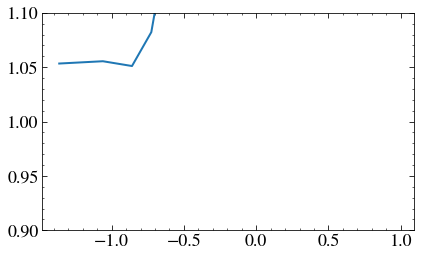

In [32]:
ks_tng = Pk2["k"][:190]
logks_tng = np.log10(ks_tng)
plt.plot(logks_tng[:190], Pk2["power"][:190]/Pk_ic["power"][:190]/gf)
plt.ylim(0.9,1.1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


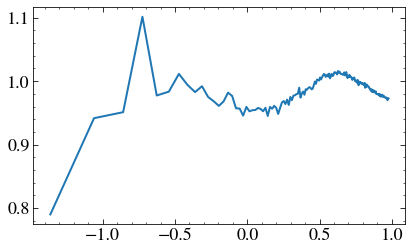

In [34]:
plt.plot(logks_tng, Pk2["power"][:190]/Pnl(ks_tng))